# 2 · Structure discovery: invariants, coordinates and skeletons

A human modeller rarely fits raw variables straight away. They first look for **conserved quantities**,
**natural coordinates** and **structural hypotheses**, then fit. `eqdisc` turns each of these steps into a tool that an
agent can call:

| tool | what it does |
|---|---|
| `coordinates.find_invariants` | sparse search for H(x) with dH/dt ≈ 0, which can be a *constraint* (it removes a dimension) or a *first integral* |
| `coordinates.make_coords` / `transform_data` / `map_back` | fit in z = φ(x), then map the model back exactly by the chain rule |
| `toolbox.fit_skeleton` | LLM-SR style: fit p0, p1, … in a proposed structure |

All scores below come from the hidden test set.

In [1]:
import os, sys, json, warnings
warnings.filterwarnings("ignore")
ROOT = os.path.abspath("..") if os.path.basename(os.getcwd()) == "notebooks" else os.getcwd()
os.chdir(ROOT); sys.path.insert(0, ROOT)
import numpy as np, matplotlib.pyplot as plt, pandas as pd
from IPython.display import display, Markdown, Math
import sympy as sp
plt.rcParams.update({"figure.dpi": 110, "axes.spines.top": False, "axes.spines.right": False})
from eqdisc import toolbox as tb, coordinates as co, plots, solvers
from eqdisc.evaluate import evaluate, load
from eqdisc.datagen import generate, add_noise, simulate, NOISE_TYPES
from eqdisc.systems import SYSTEMS

def show_eqs(rhs, title=None):
    """Pretty-print a model {var: expr} as LaTeX."""
    if title: display(Markdown(f"**{title}**"))
    for v, e in rhs.items():
        names = list(rhs) + ["t", "x"] + [f"{v}_{'x'*k}" for k in range(1, 5)]
        expr = solvers.parse(e, names) if isinstance(e, str) else e
        expr = expr.xreplace({a: sp.Float(float(a), 3) for a in expr.atoms(sp.Float)})
        display(Math(rf"\dot{{{sp.latex(sp.Symbol(v))}}} = {sp.latex(expr)}"))

def scorecard(dataset, rhs, label=""):
    r = evaluate(dataset, {"rhs": rhs}, reveal=True)
    return {"model": label, "score": round(r["score"], 2), "vf_nrmse": f"{r['vf_nrmse']:.2e}",
            "rollout_nrmse": f"{r['rollout_nrmse']:.2e}", "terms": r["n_terms"], "F1": round(r["f1"], 2),
            "coef_err": None if r["coef_rel_err"] is None else round(r["coef_rel_err"], 3)}

from IPython.display import Image

## 2.1 SIR: a constraint makes SINDy fail, and removing it fixes SINDy
S + I + R = 1 makes the library columns collinear, so SINDy returns dozens of terms.

In [2]:
d = generate("sir", noise=0.01, plot=False); m, D = load(d)
inv = co.find_invariants(m, D)
for i in inv["invariants"]:
    print(f"{i['kind'][:10]:10s}  rel_var={i['rel_variation']:.4f}  H = {i['H']}   values={np.round(i['value_per_trajectory'], 3)}")
raw = tb.run_sindy(m, D)
c = co.make_coords(m, {"S": "S", "I": "I"}, {"S": "S", "I": "I", "R": "1 - S - I"}, "reduced")
mz, Dz, _ = co.transform_data(m, D, c)
red = tb.run_sindy(mz, Dz, poly_degree=2)
back = co.map_back(red["rhs"], c)
show_eqs(back, "SINDy in reduced coordinates (S, I), mapped back")
pd.DataFrame([scorecard(d, raw["rhs"], "SINDy raw (S,I,R)"), scorecard(d, back, "SINDy reduced + map back"),
              scorecard(d, SYSTEMS["sir"].rhs, "truth")])

constraint  rel_var=0.0085  H = (1.011)*S + (1.005)*I + (1)*R   values=[1.002 1.002 1.002 1.003]


**SINDy in reduced coordinates (S, I), mapped back**

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

,model,score,vf_nrmse,rollout_nrmse,terms,F1,coef_err
0,"SINDy raw (S,I,R)",2.63,6.72e-03,2.75e-03,12,0.25,0.1
1,SINDy reduced + map back,3.54,8.36e-04,6.28e-04,5,0.89,0.0
2,truth,6.42,0.00e+00,8.91e-16,4,1.00,0.0


## 2.2 Lotka–Volterra: a first integral
The invariant search (with log terms) finds H = d·x − c·ln x + b·y − a·ln y, and its level sets *are* the orbits. This is structural insight even when it does not improve the fit. In log coordinates the dynamics are linear in exp(·) and the exact structure is recovered. Here, though, raw SINDy is already exact and *more accurate*, because the log amplifies noise near x ≈ 0. The agent has to make that call by validation, not by habit.

H = (-0.0929)*x + (-0.366)*y + (0.373)*log(x) + (1)*log(y)  rel_variation = 0.0156


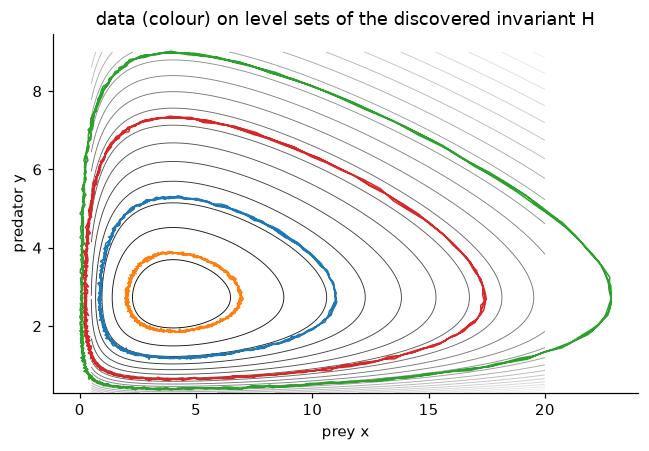

**SINDy in log coordinates**

<IPython.core.display.Math object>

<IPython.core.display.Math object>

**mapped back**

<IPython.core.display.Math object>

<IPython.core.display.Math object>

,model,score,vf_nrmse,rollout_nrmse,terms,F1,coef_err
0,SINDy raw,3.19,7.74e-04,3.69e-03,4,1.0,0.001
1,log coords,2.31,3.20e-03,5.14e-02,4,1.0,0.003
2,truth,6.42,0.00e+00,2.11e-12,4,1.0,0.000


In [3]:
d = generate("lotka_volterra", noise=0.01, plot=False); m, D = load(d)
inv = co.find_invariants(m, D, poly_degree=1, include_log=True)["invariants"][0]
print("H =", inv["H"], " rel_variation =", round(inv["rel_variation"], 4))
coef = {t.split("*", 1)[1]: float(t.split(")")[0].strip("(")) for t in inv["H"].split(" + ")}
X, Y = np.meshgrid(np.linspace(0.5, 20, 300), np.linspace(0.3, 9, 300))
H = sum(c_ * {"x": X, "y": Y, "log(x)": np.log(X), "log(y)": np.log(Y)}[k] for k, c_ in coef.items())
fig, ax = plt.subplots(figsize=(6, 4.2))
ax.contour(X, Y, H, levels=25, cmap="Greys", linewidths=0.6)
for j in range(D["U"].shape[0]):
    ax.plot(D["U"][j, :, 0], D["U"][j, :, 1], lw=1)
ax.set(xlabel="prey x", ylabel="predator y", title="data (colour) on level sets of the discovered invariant H")
plt.tight_layout(); plt.show()
c = co.make_coords(m, {"p": "log(x)", "q": "log(y)"}, None, "log")
mz, Dz, _ = co.transform_data(m, D, c)
r = tb.run_sindy(mz, Dz, poly_degree=0, custom_terms=["exp(p)", "exp(q)"])
show_eqs(r["rhs"], "SINDy in log coordinates"); show_eqs(co.map_back(r["rhs"], c), "mapped back")
pd.DataFrame([scorecard(d, tb.run_sindy(m, D)["rhs"], "SINDy raw"), scorecard(d, co.map_back(r["rhs"], c), "log coords"),
              scorecard(d, SYSTEMS["lotka_volterra"].rhs, "truth")])

## 2.3 Hopf normal form: polar coordinates
In (x, y) the model needs 8 cubic terms. In (r, θ) it is ṙ = μr − r³ and θ̇ = 1. Here a skeleton fit gives the exact structure.

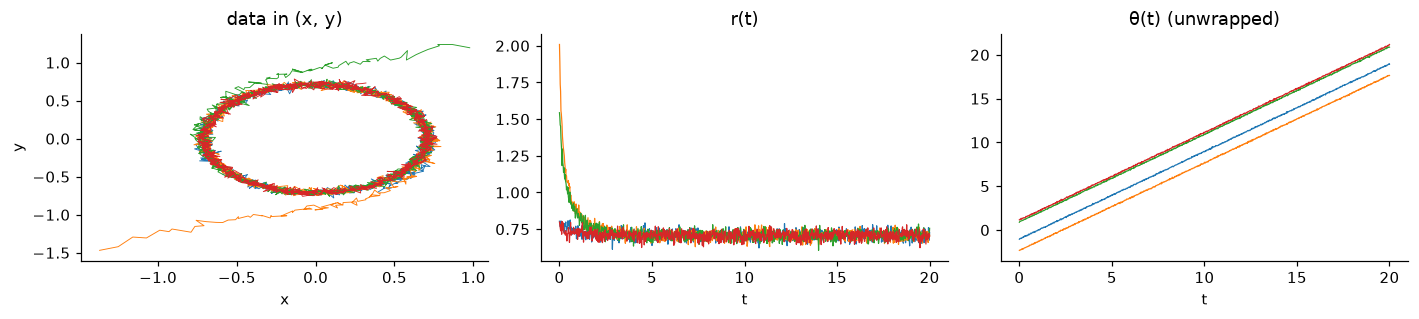

**skeleton fit in polar coordinates**

<IPython.core.display.Math object>

<IPython.core.display.Math object>

**mapped back to (x, y)**

<IPython.core.display.Math object>

<IPython.core.display.Math object>

,model,score,vf_nrmse,rollout_nrmse,terms,F1,coef_err
0,"SINDy (x,y)",0.19,3.12e-01,1.14e+00,2,0.4,0.025
1,polar skeleton,2.32,1.06e-02,1.05e-02,8,1.0,0.027
2,truth,6.34,0.00e+00,3.23e-14,8,1.0,0.000


In [4]:
d = generate("hopf", noise=0.05, plot=False); m, D = load(d)
c = co.make_coords(m, {"r": "sqrt(x**2+y**2)", "theta": "atan2(y,x)"}, {"x": "r*cos(theta)", "y": "r*sin(theta)"}, "polar")
mz, Dz, info = co.transform_data(m, D, c)
fig, axes = plt.subplots(1, 3, figsize=(13, 3))
for j in range(D["U"].shape[0]):
    axes[0].plot(D["U"][j, :, 0], D["U"][j, :, 1], lw=0.6)
    axes[1].plot(Dz["t"], Dz["U"][j, :, 0], lw=0.8); axes[2].plot(Dz["t"], Dz["U"][j, :, 1], lw=0.8)
axes[0].set(title="data in (x, y)", xlabel="x", ylabel="y"); axes[1].set(title="r(t)", xlabel="t"); axes[2].set(title="θ(t) (unwrapped)", xlabel="t")
plt.tight_layout(); plt.show()
sk = tb.fit_skeleton(mz, Dz, {"r": "p0*r + p1*r**3", "theta": "p2"})
show_eqs(sk["rhs"], "skeleton fit in polar coordinates"); show_eqs(co.map_back(sk["rhs"], c), "mapped back to (x, y)")
pd.DataFrame([scorecard(d, tb.run_sindy(m, D)["rhs"], "SINDy (x,y)"), scorecard(d, co.map_back(sk["rhs"], c), "polar skeleton"),
              scorecard(d, SYSTEMS["hopf"].rhs, "truth")])

## 2.4 Non-polynomial structure: skeleton fitting
Michaelis–Menten kinetics (ṡ = V − k·s/(K + s)) and the damped pendulum (sin θ). A polynomial library *cannot* express these; a proposed structure with free parameters can.

**Michaelis–Menten skeleton fit**

<IPython.core.display.Math object>

**truth**

<IPython.core.display.Math object>

**pendulum skeleton fit (5% red noise)**

<IPython.core.display.Math object>

<IPython.core.display.Math object>

,model,score,vf_nrmse,rollout_nrmse,terms,F1,coef_err
0,MM: SINDy poly-3,0.97,5.46e-01,1.47e-01,4,0.33,0.407
1,MM: skeleton,3.02,3.44e-03,2.20e-03,2,0.50,0.008
2,pendulum: SINDy,0.77,2.21e-02,1.40e+00,3,0.33,0.005
3,pendulum: skeleton,2.53,1.35e-03,4.58e-02,3,1.00,0.020


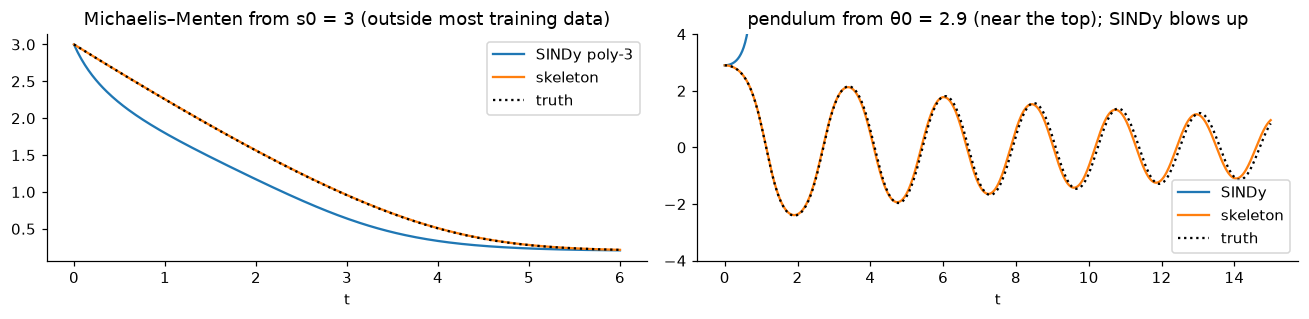

In [5]:
out = []
d = generate("michaelis_menten", noise=0.01, plot=False); m, D = load(d)
poly = tb.run_sindy(m, D)
skel = tb.fit_skeleton(m, D, {"s": "p0 - p1*s/(p2 + s)"})
show_eqs(skel["rhs"], "Michaelis–Menten skeleton fit"); show_eqs(SYSTEMS["michaelis_menten"].rhs, "truth")
out += [scorecard(d, poly["rhs"], "MM: SINDy poly-3"), scorecard(d, skel["rhs"], "MM: skeleton")]
d2 = generate("pendulum", noise=0.05, noise_type="red", plot=False); m2, D2 = load(d2)
p2 = tb.run_sindy(m2, D2)
s2 = tb.fit_skeleton(m2, D2, {"theta": "omega", "omega": "-p0*sin(theta) - p1*omega"})
show_eqs(s2["rhs"], "pendulum skeleton fit (5% red noise)")
out += [scorecard(d2, p2["rhs"], "pendulum: SINDy"), scorecard(d2, s2["rhs"], "pendulum: skeleton")]
display(pd.DataFrame(out))
fig, axes = plt.subplots(1, 2, figsize=(12, 3))
t = D["t"]; val = D["U"][-1, :, 0]
for rhs, lab in [(poly["rhs"], "SINDy poly-3"), (skel["rhs"], "skeleton")]:
    axes[0].plot(t, solvers.integrate_ode(["s"], rhs, [3.0], t)[:, 0], label=lab)
axes[0].plot(t, solvers.integrate_ode(["s"], SYSTEMS["michaelis_menten"].rhs, [3.0], t)[:, 0], "k:", label="truth")
axes[0].set(title="Michaelis–Menten from s0 = 3 (outside most training data)", xlabel="t"); axes[0].legend()
for rhs, lab in [(p2["rhs"], "SINDy"), (s2["rhs"], "skeleton")]:
    axes[1].plot(D2["t"], solvers.integrate_ode(["theta", "omega"], rhs, [2.9, 0.0], D2["t"])[:, 0], label=lab)
axes[1].plot(D2["t"], solvers.integrate_ode(["theta", "omega"], SYSTEMS["pendulum"].rhs, [2.9, 0.0], D2["t"])[:, 0], "k:", label="truth")
axes[1].set(title="pendulum from θ0 = 2.9 (near the top); SINDy blows up", xlabel="t", ylim=(-4, 4)); axes[1].legend()
plt.tight_layout(); plt.show()

## 2.5 PDE invariants: conservation laws of KdV
The search over spatial integrals finds ∫u (mass) and ∫u² (momentum) conserved. This is a strong hint that the right-hand side is in *flux form*.

rel_var=0.0055  mean_x[(1)*u]
rel_var=0.0096  mean_x[(-0.2854)*u + (1)*u*u + (-0.04302)*u*u_xx + (-0.006304)*u_xx*u_xx]
dropped as integration-by-parts identities: ['u_x*u_x']


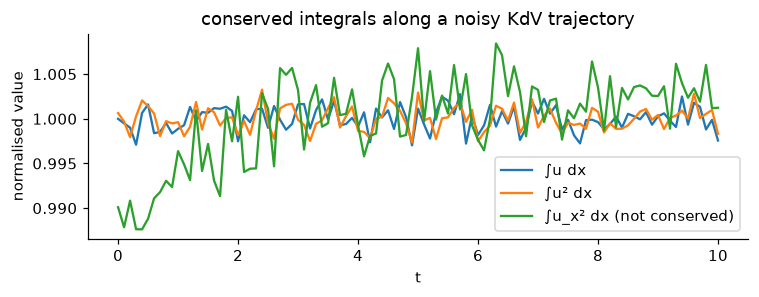

In [6]:
d = generate("kdv", noise=0.01, plot=False); m, D = load(d)
inv = co.find_invariants(m, D, poly_degree=2)
for i in inv["invariants"]:
    print(f"rel_var={i['rel_variation']:.4f}  {i['H'][:90]}")
print("dropped as integration-by-parts identities:", inv["dropped_as_identities_on_data"])
U = D["U"][0, :, :, 0]
fig, ax = plt.subplots(figsize=(7, 2.8))
for f, lab in [(U.mean(1), "∫u dx"), ((U**2).mean(1), "∫u² dx"), ((np.gradient(U, axis=1) ** 2).mean(1), "∫u_x² dx (not conserved)")]:
    ax.plot(D["t"], f / np.abs(f).mean(), label=lab)
ax.set(xlabel="t", ylabel="normalised value", title="conserved integrals along a noisy KdV trajectory"); ax.legend()
plt.tight_layout(); plt.show()